In [1]:
import os
import copy
import logging
import h5py as h5
import numpy as np
import pandas as pd
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib

import matplotlib.cm as cm



# ------------------------------
# Plot style
# ------------------------------
matplotlib.rcParams.update({
    'font.size': 20,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.major.size': 6,
    'ytick.minor.size': 3,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.minor.width': 0.8,
    'ytick.minor.width': 0.8,
    'xtick.top': True,
    'ytick.right': True,
    'xtick.bottom': True,
    'ytick.left': True,
    
    'text.usetex': True,  # Enable LaTeX rendering
    'font.family': 'serif',
    'font.serif': ['Computer Modern'],  # LaTeX default font
})

Zsun = 0.02  
threshold = 1.00 #threshold for MRR, mB > threshold * mA
# ------------------------------
# Load COMPAS data
# ------------------------------

with h5.File("processed_yields_COMPAS.h5", "r") as f:
    z_vals_compas = f["z_values"][()]
    Y_compas      = f["yields"][()]

    # LVK defined M1
    m1_compas     = np.maximum(f["event_properties/mass_1"][()],
                                f["event_properties/mass_2"][()])
    m2_compas     = np.minimum(f["event_properties/mass_1"][()],
                                f["event_properties/mass_2"][()])
    
    MRR_bh_compas = (f["event_properties/mass_2"][()] > threshold *
                     f["event_properties/mass_1"][()])

    Z_compas      = f["event_properties/metallicity"][()]  
    logZrel_compas  = np.log10(Z_compas / Zsun)

    # Just ensure we are grabbing M1 and M2 ZAMS. 
    zams1_compas  = np.maximum(f["event_properties/zams_mass_1"][()],
                                f["event_properties/zams_mass_2"][()])
    zams2_compas  = np.minimum(f["event_properties/zams_mass_1"][()],
                                f["event_properties/zams_mass_2"][()])
    
    delay_time_compas = f["event_properties/delay_time_in_years"][()]  

    # MASSquerade

    m1_compas_binary_assumption = f["event_properties/mass_1"][()]
    m2_compas_binary_assumption = f["event_properties/mass_2"][()]

# ------------------------------
# Load SEVN data
# ------------------------------

# with h5.File("processed_yields_SEVN.h5", "r") as f:
with h5.File("../data/yields/sevn_updated.hdf5", "r") as f:
    z_vals_sevn = f["z_values"][()]
    Y_sevn      = f["yields"][()]

    m1_sevn     = np.maximum(f["event_properties/mass_1"][()],
                              f["event_properties/mass_2"][()])
    m2_sevn     = np.minimum(f["event_properties/mass_1"][()],
                              f["event_properties/mass_2"][()])
    MRR_bh_sevn = (f["event_properties/mass_2"][()] > threshold *
                   f["event_properties/mass_1"][()])

    Z_sevn      = f["event_properties/metallicity"][()]
    logZrel_sevn  = np.log10(Z_sevn / Zsun)

    zams1_sevn  = np.maximum(f["event_properties/zams_mass_1"][()],
                              f["event_properties/zams_mass_2"][()])
    zams2_sevn  = np.minimum(f["event_properties/zams_mass_1"][()],
                                f["event_properties/zams_mass_2"][()])

    delay_time_sevn = f["event_properties/delay_time_in_years"][()]  

    # MASSquerade

    m1_sevn_binary_assumption = f["event_properties/mass_1"][()]
    m2_sevn_binary_assumption = f["event_properties/mass_2"][()]


In [2]:
df = pd.read_csv('../data/detailed_channels_sevn.csv')

unique_names = df["name"].drop_duplicates().reset_index(drop=True)

In [3]:
# I messed up my random seed, so some of the events don't map between my hpc data and my local machine
# As such, I went through and found systems which were close enough as representatives for the evolutionary channel.

target_mass = 119

idx = (df["Mass_0"] - target_mass).abs().idxmin()
closest_row = df.loc[idx]

closest_name = closest_row["name"]

print("Closest name:", closest_name)
print("Mass_0 value:", closest_row["Mass_0"])

df_first_event = df[df["name"]==closest_name]

Closest name: 671207034676983.0
Mass_0 value: 118.9998


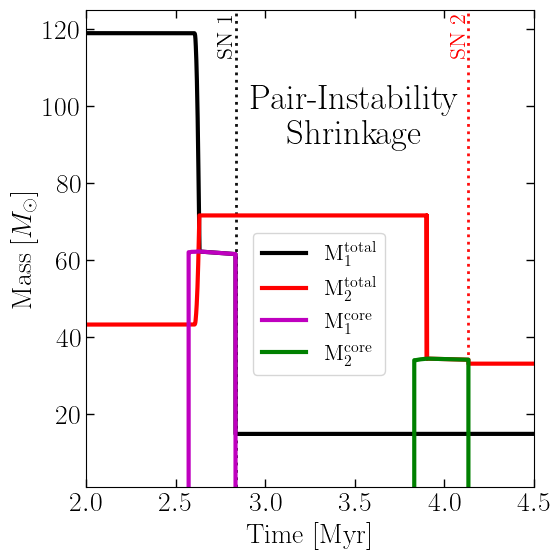

In [4]:
# ── Config ────────────────────────────────────────────────────────────────────
time_col       = "BWorldtime"
exclude_events = {-1, 0}     # ignore "No Event" and "CPhase"
x_limits       = (2, 4.5)    # visible time window

# SN markers
sn_fs        = 16
sn_linestyle = ":"

# ── Prep ──────────────────────────────────────────────────────────────────────
log = df_first_event.copy()
log["BEvent"] = log["BEvent"].astype(int)
log = log.sort_values(time_col).reset_index(drop=True)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(log[time_col], log["Mass_0"], label=r"M$_1^{\rm total}$", lw=3, c='k')
ax.plot(log[time_col], log["Mass_1"], label=r"M$_2^{\rm total}$", lw=3, c='r')
ax.plot(log[time_col], log["MHE_0"],  label=r"M$_{1}^{\rm core}$", c='m', lw=3)
ax.plot(log[time_col], log["MHE_1"],  label=r"M$_{2}^{\rm core}$", c='g', lw=3)

ax.set_xlim(x_limits)
ax.set_ylim(1, 125)
ax.set_xlabel("Time [Myr]")
ax.set_ylabel(r"Mass [$M_\odot$]")

x_min, x_max = ax.get_xlim()
ymin, ymax   = ax.get_ylim()
dy           = ymax - ymin

# ── SN markers ────────────────────────────────────────────────────────────────
def plot_sn_for_star(star_idx, c):
    phase_col = f"Phase_{star_idx}"
    if phase_col not in log.columns:
        return
    ph      = log[phase_col]
    changed = ph.ne(ph.shift())
    rows    = log.loc[changed & (ph == 7), [time_col, phase_col]]
    rows    = rows[(rows[time_col] >= x_min) & (rows[time_col] <= x_max)]
    for t in rows[time_col].to_numpy():
        ax.axvline(t, color=c, lw=2, ls=sn_linestyle, alpha=0.95, zorder=1)
        ax.text(t - 0.05, ymax - 0.005*dy, f"SN {star_idx+1}",
                va="top", ha="center", fontsize=sn_fs, color=c, zorder=2, rotation=90)

plot_sn_for_star(0, c='k')
plot_sn_for_star(1, c='r')

ax.legend(
    fontsize=16,
    loc="upper center",
    bbox_to_anchor=(3.3, 70),
    bbox_transform=ax.transData,
)
ax.text(3.5, 90.0, "Pair-Instability \n Shrinkage", fontsize=25, ha='center')

plt.tight_layout()
#plt.savefig("../plots/final-sevn-pisn-shrink.pdf")
plt.show()

## core growth

In [5]:
target_mass = 60

idx = (df["Mass_0"] - target_mass).abs().idxmin()
closest_row = df.loc[idx]

closest_name = closest_row["name"]

print("Closest name:", closest_name)
print("Mass_0 value:", closest_row["Mass_0"])
df_first_event = df[df["name"]==closest_name	]

Closest name: 157183786771173.0
Mass_0 value: 59.9999


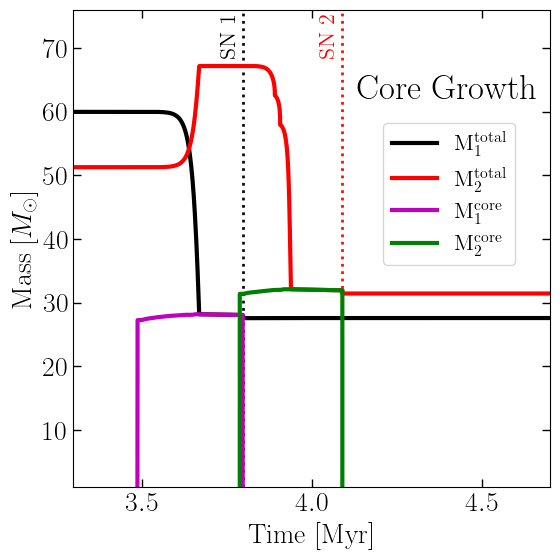

In [6]:
# ── Config ────────────────────────────────────────────────────────────────────
time_col     = "BWorldtime"
x_limits     = (3.3, 4.7)
sn_fs        = 16
sn_linestyle = ":"

# ── Prep ──────────────────────────────────────────────────────────────────────
log = df_first_event.copy()
log["BEvent"] = log["BEvent"].astype(int)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(log[time_col], log["Mass_0"], label=r"M$_1^{\rm total}$", lw=3, c='k')
ax.plot(log[time_col], log["Mass_1"], label=r"M$_2^{\rm total}$", lw=3, c='r')
ax.plot(log[time_col], log["MHE_0"],  label=r"M$_{1}^{\rm core}$", c='m', lw=3)
ax.plot(log[time_col], log["MHE_1"],  label=r"M$_{2}^{\rm core}$", c='g', lw=3)

ax.set_xlim(x_limits)
ax.set_xlabel("Time [Myr]")
ax.set_ylabel(r"Mass [$M_\odot$]")

x_min, x_max = ax.get_xlim()
ymin, ymax   = ax.get_ylim()  # auto-scaled at this point, used for SN text placement
dy           = ymax - ymin

# ── SN markers ────────────────────────────────────────────────────────────────
def plot_sn_for_star(star_idx, c):
    phase_col = f"Phase_{star_idx}"
    if phase_col not in log.columns:
        return
    ph      = log[phase_col]
    changed = ph.ne(ph.shift())
    rows    = log.loc[changed & (ph == 7), [time_col, phase_col]]
    rows    = rows[(rows[time_col] >= x_min) & (rows[time_col] <= x_max)]
    for t in rows[time_col].to_numpy():
        ax.axvline(t, color=c, lw=2, ls=sn_linestyle, alpha=0.95, zorder=1)
        ax.text(t - 0.04, ymax + 5, f"SN {star_idx+1}",
                va="top", ha="center", fontsize=sn_fs, color=c, zorder=2, rotation=90)

plot_sn_for_star(0, c='k')
plot_sn_for_star(1, c='r')

ax.set_ylim(1, 76)  # set after SN text placement so ymax above refers to auto-scaled value

ax.legend(
    fontsize=16,
    loc="upper right",
    bbox_to_anchor=(4.63, 60),
    bbox_transform=ax.transData,
)
ax.text(4.4, 62.0, "Core Growth", fontsize=25, ha='center')

plt.tight_layout()
# plt.savefig("../plots/final-sevn-core-growth.pdf")
plt.show()

# Asymmetric CCSN